# Built in module for nural network and optimization 
- The nn module
- The torch.optim module


- Build a nural network using nn module 
- Use built-in loss function 
- Use built-in activation function using nn module
- Use built-in optimizer
    - performe greadint descent using nn module

## The nn module
The torch.nn module in PyTorch is a core library that provides a wide array of classes and functions designed to help developers build neural networks efficiently and effectively. It abstracts the complexity of creating and training neural networks by offering pre-built layers, loss functions, activation functions, and other utilities, enabling you to focus on designing and experimenting with model architectures.

### key Components of torch.nn:
1) Modulel (Layers):
    - nn.Module: The base class for all neural network modules. Your custom models and layers should subclass this class.
    - Common Layers: Includes layers like nn. Linear (fully connected layer), nn. Conv2d (convolutional layer), nn.LSTM (recurrent layer), and many others.
2) Activation Functions:
    - Functions like nn.ReLU, nn.Sigmoid, and nn.Tanh introduce non-linearities to the model, allowing it to learn complex patterns.
3) Loss Functions:
    - Provides loss functions such as nn. CrossEntropyLoss, nn.MSELoss, and nn.NLLLoss to quantify the difference between the model's predictions and the actual targets.
4) Container Modules:
    - nn.Sequential: A sequential container to stack layers in order.
5) Regularization and Dropout:
    - Layers like nn. Dropout and nn.BatchNorm2d help prevent overfitting and improve the model's ability to generalize to new data.

In [3]:
import torch 
import torch.nn as nn 


In [4]:
class Model(nn.Module):

    def __init__ (self, num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1) # (num of inputs, num of outputs)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):

        out = self.linear(features)
        out = self.sigmoid(out)

        return out


    

In [6]:
# create dataset

features = torch.rand(10,5)

# create model
model = Model(features.shape[1])

# call model for forward pass
# model.forward(features)
model(features)

tensor([[0.5974],
        [0.5455],
        [0.5813],
        [0.5929],
        [0.6163],
        [0.5295],
        [0.6224],
        [0.4845],
        [0.5168],
        [0.5090]], grad_fn=<SigmoidBackward0>)

In [7]:
# show waights
model.linear.weight, model.linear.bias

(Parameter containing:
 tensor([[-0.1557,  0.3154, -0.3845, -0.2345,  0.2847]], requires_grad=True),
 Parameter containing:
 tensor([0.2886], requires_grad=True))

In [8]:
!pip install torchinfo

In [9]:
from torchinfo import summary
summary(model, input_size=(10, 5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# Let's create the given neural network
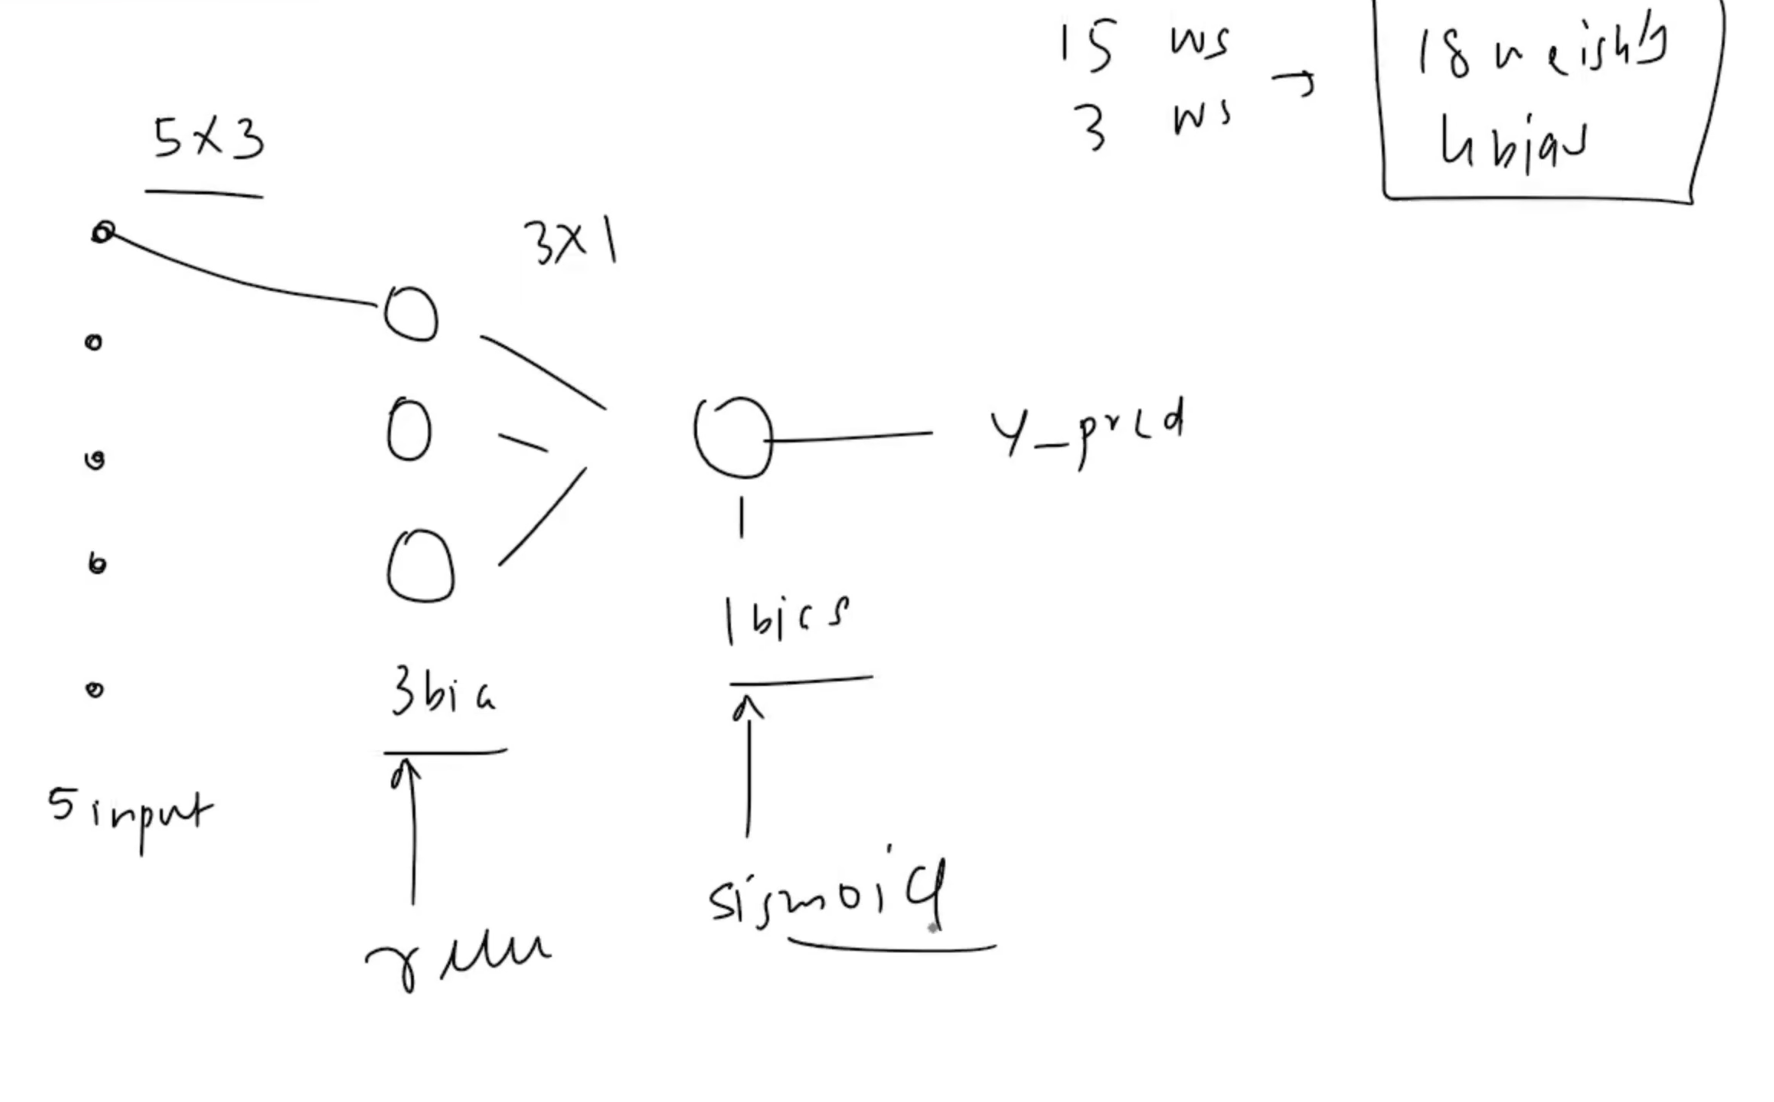

In [11]:
class Model2(nn.Module):

    def __init__ (self, num_features):
        super().__init__()
        self.linear1 = nn.Linear(num_features, 3) # (num of inputs, num of outputs)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):

        out = self.linear1(features)
        out = self.relu(out)
        out = self.linear2(out)
        out = self.sigmoid(out)

        return out


In [13]:
# creating model
model2 = Model2(features.shape[1])

# calling forward pass
model2(features)

tensor([[0.4062],
        [0.4043],
        [0.4048],
        [0.4048],
        [0.4048],
        [0.4029],
        [0.4048],
        [0.4020],
        [0.4029],
        [0.4030]], grad_fn=<SigmoidBackward0>)

In [18]:
model2.linear1.weight

Parameter containing:
tensor([[-0.4143, -0.1326, -0.2357, -0.2357, -0.3134],
        [-0.1479,  0.0570,  0.2397, -0.1527,  0.3044],
        [ 0.0299, -0.3082,  0.3944,  0.2852, -0.2530]], requires_grad=True)

In [19]:
from torchinfo import summary
summary(model2, input_size=(10, 5))

Layer (type:depth-idx)                   Output Shape              Param #
Model2                                   [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

- Sequential Container

In [21]:
class Model3(nn.Module):

    def __init__ (self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 3), # (num of inputs, num of outputs)
            nn.ReLU(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )
        

    def forward(self, features):
        out = self.network(features)

        return out

In [22]:
# creating model
model3 = Model3(features.shape[1])

# calling forward pass
model3(features)

tensor([[0.5115],
        [0.5211],
        [0.5198],
        [0.5198],
        [0.5255],
        [0.5260],
        [0.5384],
        [0.5213],
        [0.5122],
        [0.5191]], grad_fn=<SigmoidBackward0>)

- Built-in loss finction 

In [23]:
class Model3(nn.Module):

    def __init__ (self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 3), # (num of inputs, num of outputs)
            nn.ReLU(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )
        

    def forward(self, features):
        out = self.network(features)

        return out

In [25]:
# Built-in BCEloss
loss_function = nn.BCELoss()

# torch.optim
- torch.optim is a module in PyTorch that provides a variety of optimization algorithms used to update the parameters of your model during training.
- It includes common optimizers like Stochastic Gradient Descent (SGD), Adam, RMSprop, and more.
- It handles weight updates efficiently, including additional features like learning rate scheduling and weight decay (regularization).
1) The model.parameters() method in PyTorch retrieves an iterator over all the trainable parameters (weights and biases) in a model. These parameters are instances of torch.nn.Parameter and include:
    - Weights: The weight matrices of layers like nn.Linear, nn. Conv2d, etc.
    - Biases: The bias terms of layers (if they exist).
    - The optimizer uses these parameters to compute gradients and update them during training.

In [26]:
# define optimizer 
optimizer = torch.optim.SGD(model.parameters(), lr = 0.2)

In [28]:
# optimizer.step() to update parameters
# optimizer.zero_grad() to make gradiants zero